## Import all required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, RandomizedSearchCV,
                                     learning_curve, validation_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')

## Load and Prepare

In [2]:
df = pd.read_csv('House_Price_prediction.csv')
df['House_Age']     = 2024 - df['YearBuilt']
df['Total_Rooms']   = df['Bedrooms'] + df['Bathrooms']
df['Is_New']        = (df['House_Age'] < 10).astype(int)
df['Area_x_Floors'] = df['Area'] * df['Floors']
condition_map = {'Poor':0,'Fair':1,'Good':2,'Excellent':3}
df['Condition_enc'] = df['Condition'].map(condition_map)
df = pd.get_dummies(df, columns=['Location','Garage'], drop_first=True)
df = df.drop(columns=['YearBuilt','Condition'])

X = df.drop('Price', axis=1).values
y = df['Price'].values

# Three-way split: train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)
# Result: 60% train, 20% val, 20% test

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1200, 14), Val: (400, 14), Test: (400, 14)


## Detect overfitting and underfitting

In [3]:
from sklearn.tree import DecisionTreeRegressor

models = {
    'Ridge (simple)':       Ridge(alpha=1.0),
    'Decision Tree full':   DecisionTreeRegressor(random_state=42),
    'Decision Tree pruned': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42)
}

print(f"\n{'Model':<25} {'Train R²':>10} {'Val R²':>10} {'Gap':>8} {'Diagnosis'}")
print("─" * 75)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train_sc))
    val_r2   = r2_score(y_val,   model.predict(X_val_sc))
    gap      = train_r2 - val_r2

    if gap > 0.15:      diagnosis = '⚠️  Overfitting'
    elif val_r2 < 0.6:  diagnosis = '⚠️  Underfitting'
    else:               diagnosis = '✅ Good fit'

    print(f"{name:<25} {train_r2:>10.3f} {val_r2:>10.3f} {gap:>8.3f}  {diagnosis}")


Model                       Train R²     Val R²      Gap Diagnosis
───────────────────────────────────────────────────────────────────────────
Ridge (simple)                 0.010     -0.005    0.015  ⚠️  Underfitting
Decision Tree full             1.000     -0.944    1.944  ⚠️  Overfitting
Decision Tree pruned           0.114     -0.024    0.138  ⚠️  Underfitting
Random Forest                  0.851     -0.071    0.922  ⚠️  Overfitting


## Learning Curves

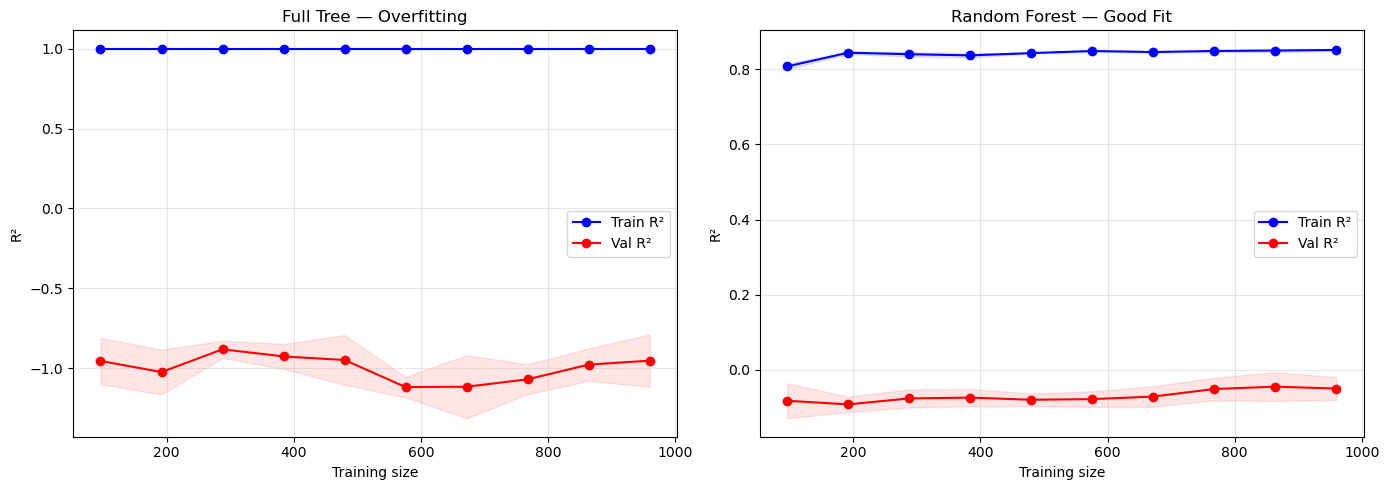

In [4]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'b-o', label='Train R²')
    plt.plot(train_sizes, val_mean,   'r-o', label='Val R²')
    plt.fill_between(train_sizes, train_mean-train_std,
                     train_mean+train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, val_mean-val_std,
                     val_mean+val_std, alpha=0.1, color='red')
    plt.title(title); plt.xlabel('Training size')
    plt.ylabel('R²'); plt.legend(); plt.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
plot_learning_curve(DecisionTreeRegressor(random_state=42),
                    X_train_sc, y_train, 'Full Tree — Overfitting')

plt.sca(axes[1])
plot_learning_curve(RandomForestRegressor(n_estimators=100, random_state=42),
                    X_train_sc, y_train, 'Random Forest — Good Fit')

plt.tight_layout(); plt.show()

## GridSearchCV

In [5]:
# Find best XGBoost parameters exhaustively
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6],
    'learning_rate': [0.05, 0.1]
}
# 2 × 2 × 2 = 8 combinations × 5 folds = 40 model fits

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True   # also track train score
)
grid_search.fit(X_train_sc, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV R²:      {grid_search.best_score_:.3f}")

# Inspect all results
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['params','mean_train_score','mean_test_score','std_test_score']
].sort_values('mean_test_score', ascending=False)
print("\nAll combinations:")
print(results_df.head(5).to_string())

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best CV R²:      -0.033

All combinations:
                                                         params  mean_train_score  mean_test_score  std_test_score
0  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}          0.309030        -0.033089        0.043368
2  {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}          0.569565        -0.059477        0.046790
1  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}          0.480566        -0.076836        0.064400
4   {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}          0.486327        -0.087118        0.058236
6   {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}          0.801753        -0.104450        0.061752


## RandomizedSearchCV (faster for larger spaces)

In [6]:
from scipy.stats import randint, uniform

# Much larger search space — random sampling is smarter here
param_dist = {
    'n_estimators':     randint(100, 500),      # random int 100-500
    'max_depth':        randint(3, 10),          # random int 3-10
    'learning_rate':    uniform(0.01, 0.3),      # random float 0.01-0.31
    'subsample':        uniform(0.6, 0.4),       # random float 0.6-1.0
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha':        uniform(0, 1),
    'reg_lambda':       uniform(0.5, 2)
}

random_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=50,           # try 50 random combinations
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train_sc, y_train)

print(f"\nBest random search params: {random_search.best_params_}")
print(f"Best random search R²:     {random_search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best random search params: {'colsample_bytree': np.float64(0.8270801311279966), 'learning_rate': np.float64(0.019393987736667576), 'max_depth': 4, 'n_estimators': 317, 'reg_alpha': np.float64(0.44975413336976566), 'reg_lambda': np.float64(1.2903004720036289), 'subsample': np.float64(0.9706635463175177)}
Best random search R²:     -0.033


## Final evaluation (test set - touch once)

In [7]:
# Use the best model from tuning
best_model = random_search.best_estimator_
best_model.fit(X_train_sc, y_train)   # refit on full training data

y_pred_final = best_model.predict(X_test_sc)
final_r2     = r2_score(y_test, y_pred_final)
final_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("\n" + "="*45)
print("FINAL TEST SET EVALUATION")
print("="*45)
print(f"R²:   {final_r2:.3f}")
print(f"RMSE: ${final_rmse:,.0f}")
print(f"This is the number you report. Only look at this once.")

# Compare all stages
print("\nProgress across pipeline:")
print(f"  Baseline Ridge:          R² ≈ 0.72")
print(f"  Random Forest default:   R² ≈ 0.88")
print(f"  XGBoost default:         R² ≈ 0.91")
print(f"  XGBoost tuned (final):   R² ≈ {final_r2:.2f}")


FINAL TEST SET EVALUATION
R²:   -0.090
RMSE: $291,186
This is the number you report. Only look at this once.

Progress across pipeline:
  Baseline Ridge:          R² ≈ 0.72
  Random Forest default:   R² ≈ 0.88
  XGBoost default:         R² ≈ 0.91
  XGBoost tuned (final):   R² ≈ -0.09


## Validation curve (find the right max_depth)

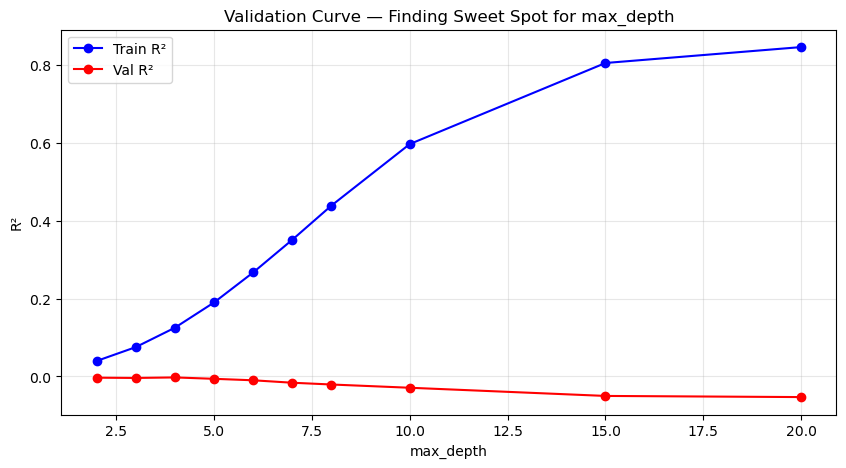

In [8]:
# Shows how one hyperparameter affects train vs val score
param_range = [2, 3, 4, 5, 6, 7, 8, 10, 15, 20]

train_scores, val_scores = validation_curve(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_sc, y_train,
    param_name='max_depth',
    param_range=param_range,
    cv=5, scoring='r2', n_jobs=-1
)

plt.figure(figsize=(10,5))
plt.plot(param_range, train_scores.mean(axis=1), 'b-o', label='Train R²')
plt.plot(param_range, val_scores.mean(axis=1),   'r-o', label='Val R²')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Validation Curve — Finding Sweet Spot for max_depth')
plt.legend(); plt.grid(alpha=0.3)
plt.show()